# Validation 전용: 유형·오차상관 → 방향/RMSE → Jev 뉴스 결합

**목적:** 원두 구매 판단에 쓸 학습 모델의 가격 오차와 방향 성능을 함께 개선할 수 있는지 확인한다. Naive/Persistence는 입력·앙상블·선택·비교 예측에 사용하지 않는다. 기존 `03_3`의 저장 예측과 `data/jev/sentiment.csv`를 재사용하며 API 호출·재수집·신경망 재학습·서비스 변경은 없다.

**기간 계약:** 2022년은 설정·조합·계수 개발, 2023년은 고정한 후보의 비교 및 최종 Validation 선택이다. 가격 모델 자체는 각 예측 연도 직전 연말까지 학습된 out-of-sample 예측이다. 기존의 2022~2023 통합 설정 선택은 재사용하지 않고 **2022년만으로 설정을 다시 고른다.** 2024~2026년 가격 예측·정답은 로딩하지 않는다. 뉴스의 전 기간 품질·건수만 확인하고, 모델 입력에는 2022~2023년 자료만 사용한다. 2023년으로 최종 선택하므로 그 점수는 독립 Test가 아니다. 이미 확인했던 2024~2025 결과도 이번 선택에 사용하지 않는다.

**선택 규칙** (전체 절차는 이미 사용한 Validation에서 수행하는 탐색 연구이며 사전등록·독립 검증이 아니다.)
1. 선형(DLinear/NLinear), 트리(XGBoost/LightGBM), Transformer(PatchTST), 주기 CNN(TimesNet) 중 2유형 이상인 2~6개 조합을 열거한다. 2022년 **가격 오차 Pearson 상관의 최대가 0.95 이하**인 조합을 남기고, 같은 구성원 수에서 평균 상관이 하위 50%인 후보를 다양성 후보군으로 둔다. 이는 임의의 연구 규칙이지 검증된 최적 임계값이 아니다. 불가능하면 기준을 조용히 완화하지 않는다. 5일에는 상대적으로 낮아도 절대 상관은 높을 수 있다.
2. 2022년 가격 RMSE 최저 모델과 균형 방향 정확도 최고 모델을 핵심으로 둔다. 같은 모델이면 방향 2위 모델을 보완 핵심으로 둔다. 두 핵심을 모두 포함한 다양성 후보에서 구성원 수별로 `가격 RMSE / RMSE 핵심의 RMSE + (1−균형 정확도) / (1−방향 핵심의 균형 정확도)`를 최소화한다. 두 상대 오차를 동등하게 취급한다. 구성원 수별 후보를 고정해 3개 이상이 실제로 유리한지도 2023년에서 확인한다. 최저 상관 후보는 1단계 진단용으로 별도 비교한다.
3. 학습 모델들의 **예측 가격을 동일 가중 산술평균**한다. 뉴스 분류 확률을 가격과 직접 평균하지 않는다. 2022년 잔차로 편향 보정과 뉴스 추가 보정을 적합해 2023년에서 원평균·편향만·편향+뉴스·역방향 허용 뉴스를 비교한다. 뉴스 추가 효과는 반드시 편향만 보정한 동일 조합과 비교한다.
4. 최종 후보는 2단계 핵심 포함 조합에서만 2023년의 위 상대 오차 합을 최소화한다(동률: 작은 가격 RMSE → 구성원 적음 → 단순한 보정 → 이름). 최저 상관 진단·전체 6개 평균·단일 모델은 비교용이다. 결과가 단일 모델보다 나쁘면 앙상블을 억지로 권장하지 않는다.

**지표:** 가격 RMSE(센트/lb), 로그수익률 RMSE, 부호 적중률, 상승/하락 재현율의 평균인 균형 정확도, 상승 정밀도/누락률. 정확한 0은 보합이며 방향 재현율에서 무신호는 실패다. 5/20/60거래일은 약 1주/1개월/3개월. 결론은 선택에 사용한 자료와 제한된 후보에 조건부다.

방법 참고: [단순평균](https://otexts.com/fpp3/combinations.html), [시간순 교차검증](https://otexts.com/fpp3/tscv.html).

In [1]:
import os, sys, json, hashlib, tempfile, platform
from pathlib import Path
from itertools import combinations
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "coffee-matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "coffee_service").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from coffee_service.transform import coffee_sessions, transform_market
from coffee_service.news_residual import signal_features, LAGS, LAG_WEIGHTS
FONT = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
assert FONT in {f.name for f in font_manager.fontManager.ttflist}, f"한글 폰트 필요: {FONT}"
plt.rcParams.update({"font.family": FONT, "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
MODELS = ("DLinear", "NLinear", "XGBoost", "LightGBM", "PatchTST", "TimesNet")
FAMILY = dict(zip(MODELS, ("선형", "선형", "트리", "트리", "Transformer", "주기 CNN")))
HORIZONS, SEED, CORR_CAP = (5, 20, 60), 42, .95
DEVELOP_END, SELECT_END = pd.Timestamp("2022-12-31"), pd.Timestamp("2023-12-31")
# 2021년 뉴스 이력이 없으므로 3일 반감기 신호의 초기 1개월은 공통 평가에서 제외한다.
START = pd.Timestamp("2022-02-01")
SOURCE = ROOT / "data/processed/single_model_comparison/20260926T115735770501Z/individual_predictions.parquet"
NEWS = ROOT / "data/jev/sentiment.csv"
MARKET = ROOT / "data/processed/2014-07-01_2025-12-31/coffee.parquet"
source_hash, news_hash, market_hash = [hashlib.sha256(p.read_bytes()).hexdigest() for p in (SOURCE, NEWS, MARKET)]
def show(frame, digits=3):
    display(Markdown(frame.to_markdown(index=False, floatfmt=f".{digits}f")))

def score(actual, predicted, current):
    y, p, c = [np.asarray(x, dtype=float) for x in (actual, predicted, current)]
    if y.ndim != 1 or not len(y) or y.shape != p.shape or y.shape != c.shape or not np.isfinite([y,p,c]).all() or (c <= 0).any():
        raise ValueError("같은 길이의 유한 예측·정답과 양수 기준 가격이 필요합니다.")
    up, down = y > 0, y < 0
    ur = np.mean(p[up] > 0) if up.any() else np.nan
    dr = np.mean(p[down] < 0) if down.any() else np.nan
    actual_price, predicted_price = c*np.exp(y), c*np.exp(p)
    if not np.isfinite([actual_price,predicted_price]).all(): raise ValueError("복원 가격 오류")
    return {"표본": len(y), "가격 RMSE": np.sqrt(np.mean((actual_price-predicted_price)**2)),
            "수익률 RMSE": np.sqrt(np.mean((y-p)**2)), "방향 적중률 (%)": 100*np.mean(np.sign(y)==np.sign(p)),
            "균형 정확도 (%)": 50*(ur+dr), "상승 정밀도 (%)": 100*np.mean(y[p>0]>0) if (p>0).any() else np.nan,
            "상승 누락률 (%)": 100*(1-ur)}

def joint_score(row, rmse_reference, direction_reference):
    denominator = 1-direction_reference/100
    if rmse_reference <= 0 or denominator <= 0: raise ValueError("상대 오차 기준이 0입니다.")
    return row["가격 RMSE"]/rmse_reference + (1-row["균형 정확도 (%)"]/100)/denominator

def price_average(predictions, members):
    if len(members)<2 or len(set(members)) != len(members) or not set(members)<=set(MODELS):
        raise ValueError("서로 다른 학습 모델만 평균합니다.")
    values = predictions.loc[:,list(members)].to_numpy(float)
    if not np.isfinite(values).all(): raise ValueError("평균 입력 오류")
    return np.logaddexp.reduce(values,axis=1)-np.log(len(members))

# Parquet 필터로 Validation만 읽고, 허용 모델만 명시적으로 남긴다.
raw = pd.read_parquet(SOURCE, filters=[("split", "==", "validation")])
raw = raw.loc[raw.model.isin(MODELS) & raw.origin_date.ge(START)].copy()
assert set(raw.model)==set(MODELS) and set(raw.seed)=={SEED}
assert set(raw.fold.astype(str))=={"2022","2023"}
assert raw.origin_date.dt.year.isin([2022,2023]).all() and raw.target_date.le(SELECT_END).all()
assert (raw.train_cutoff < raw.origin_date).all() and (raw.target_date > raw.origin_date).all()
assert not raw.duplicated(["fold","horizon","model","setting","origin_date"]).any()
assert np.isfinite(raw[["actual_return","predicted_return","current_price"]]).all().all()
setting_rows=[]
for (h,name,setting),g in raw.loc[raw.fold.eq("2022")].groupby(["horizon","model","setting"]):
    assert g.target_date.le(DEVELOP_END).all()
    setting_rows.append({"지평":h,"모델":name,"설정":setting, **score(g.actual_return,g.predicted_return,g.current_price)})
setting_scores=pd.DataFrame(setting_rows)
settings=(setting_scores.sort_values(["지평","모델","가격 RMSE","설정"]).drop_duplicates(["지평","모델"]))
chosen = raw.merge(settings[["지평","모델","설정"]], left_on=["horizon","model","setting"],
                   right_on=["지평","모델","설정"],validate="many_to_one")
def align(frame):
    reference=frame.loc[frame.model.eq(MODELS[0])].sort_values("origin_date").set_index("origin_date")
    if reference.empty or reference.index.has_duplicates: raise ValueError("기준 날짜 중복/빈 자료")
    columns=["target_date","actual_return","current_price"]
    out=pd.DataFrame(index=reference.index)
    for name in MODELS:
        sub=frame.loc[frame.model.eq(name)].sort_values("origin_date").set_index("origin_date")
        pd.testing.assert_frame_equal(reference[columns],sub[columns],check_exact=True)
        out[name]=sub.predicted_return
    return reference[columns].copy(),out
panels={(int(year),h):align(g) for (year,h),g in chosen.groupby(["fold","horizon"])}
show(settings[["지평","모델","설정","가격 RMSE","균형 정확도 (%)"]])
print("2022년만으로 선택한 설정. 신경망: epochs, 트리: n_estimators.")

|   지평 | 모델     |   설정 |   가격 RMSE |   균형 정확도 (%) |
|-------:|:---------|-------:|------------:|------------------:|
|      5 | DLinear  |     10 |      10.508 |            51.660 |
|      5 | LightGBM |    100 |      10.326 |            50.344 |
|      5 | NLinear  |     10 |       9.782 |            50.121 |
|      5 | PatchTST |     10 |      10.153 |            48.522 |
|      5 | TimesNet |     10 |      11.275 |            47.206 |
|      5 | XGBoost  |    100 |      10.241 |            52.247 |
|     20 | DLinear  |     10 |      23.601 |            62.739 |
|     20 | LightGBM |    100 |      20.864 |            49.211 |
|     20 | NLinear  |     10 |      17.582 |            58.421 |
|     20 | PatchTST |     10 |      22.381 |            41.150 |
|     20 | TimesNet |     10 |      24.412 |            51.019 |
|     20 | XGBoost  |    100 |      21.210 |            47.320 |
|     60 | DLinear  |     10 |      21.799 |            65.478 |
|     60 | LightGBM |    300 |      29.284 |            47.034 |
|     60 | NLinear  |     30 |      25.577 |            54.157 |
|     60 | PatchTST |     30 |      40.542 |            43.132 |
|     60 | TimesNet |     10 |      23.742 |            52.830 |
|     60 | XGBoost  |    300 |      29.374 |            43.644 |

2022년만으로 선택한 설정. 신경망: epochs, 트리: n_estimators.


## 1. 2022년에서 다양성과 성능 보완성 선별

상관은 실제값 자체나 예측값끼리가 아니라 **예측 가격−실제 가격 오차**로 계산한다. 낮은 상관이 낮은 오차를 보장하지 않으므로 최저 상관 조합과 핵심 모델을 함께 포함한 성능 조합을 구분한다. 3개 이상을 포함할 때도 동일 가중 평균이며, 구성원 수별 후보는 2023년을 보기 전에 고정한다.

|   지평 | RMSE 핵심   | 방향 최고   | 방향 보완 핵심   | 최저 상관 진단      | 최종 선택 허용 조합                                                                                                              |
|-------:|:------------|:------------|:-----------------|:--------------------|:---------------------------------------------------------------------------------------------------------------------------------|
|      5 | NLinear     | XGBoost     | XGBoost          | PatchTST + TimesNet | ['NLinear + XGBoost + TimesNet']                                                                                                 |
|     20 | NLinear     | DLinear     | DLinear          | DLinear + PatchTST  | ['DLinear + NLinear + PatchTST', 'DLinear + NLinear + LightGBM + PatchTST', 'DLinear + NLinear + XGBoost + PatchTST + TimesNet'] |
|     60 | DLinear     | DLinear     | NLinear          | DLinear + PatchTST  | ['DLinear + NLinear + LightGBM', 'DLinear + NLinear + PatchTST + TimesNet', 'DLinear + NLinear + XGBoost + PatchTST + TimesNet'] |

|   지평 | 조합                                              |   구성원 수 |   평균 오차상관 |   최대 오차상관 | 핵심 포함   |   가격 RMSE |   균형 정확도 (%) |   상대 오차 합 |
|-------:|:--------------------------------------------------|------------:|----------------:|----------------:|:------------|------------:|------------------:|---------------:|
|      5 | PatchTST + TimesNet                               |           2 |           0.874 |           0.874 | False       |      10.288 |            46.640 |          2.169 |
|      5 | NLinear + XGBoost + TimesNet                      |           3 |           0.905 |           0.943 | True        |      10.045 |            49.757 |          2.079 |
|     20 | DLinear + PatchTST                                |           2 |           0.575 |           0.575 | False       |      20.304 |            48.967 |          2.524 |
|     20 | DLinear + NLinear + PatchTST                      |           3 |           0.727 |           0.840 | True        |      18.721 |            52.052 |          2.352 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           |           4 |           0.795 |           0.911 | True        |      19.082 |            50.078 |          2.425 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet |           5 |           0.809 |           0.919 | True        |      19.828 |            44.937 |          2.606 |
|     60 | DLinear + PatchTST                                |           2 |           0.045 |           0.045 | False       |      21.979 |            61.337 |          2.128 |
|     60 | DLinear + NLinear + LightGBM                      |           3 |           0.695 |           0.930 | True        |      22.403 |            60.897 |          2.160 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           |           4 |           0.545 |           0.828 | True        |      21.078 |            54.717 |          2.279 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet |           5 |           0.632 |           0.901 | True        |      22.509 |            50.943 |          2.454 |

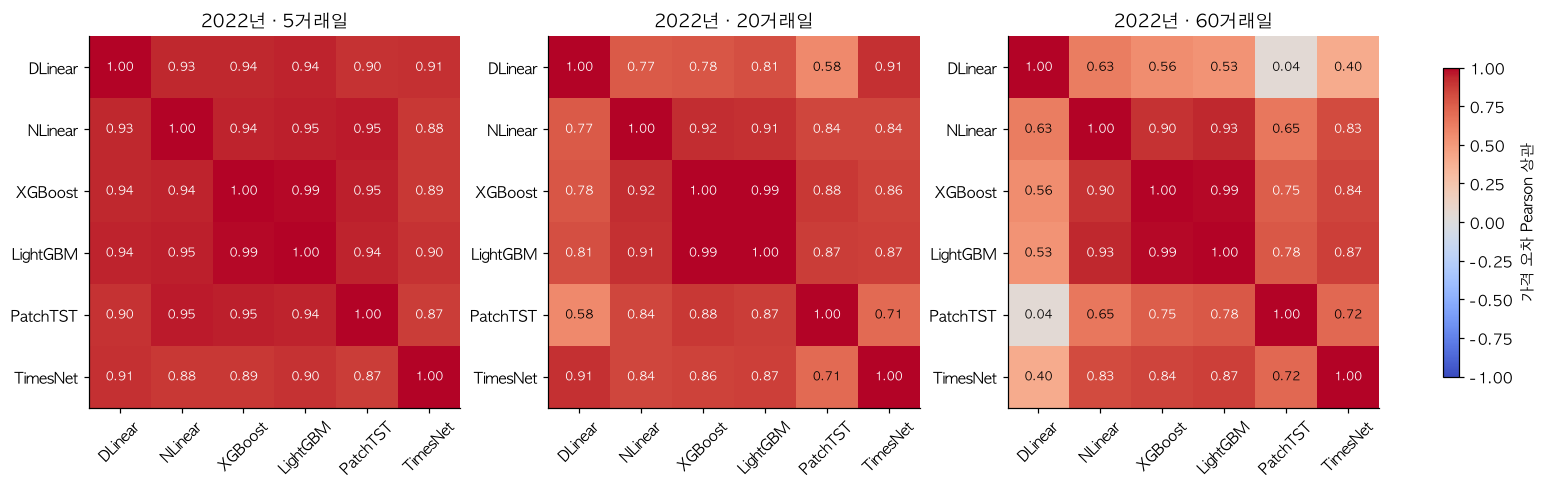

In [2]:
candidate_rows, anchor_rows, frozen, correlations = [], [], {}, {}
for h in HORIZONS:
    r,p=panels[(2022,h)]
    singles=pd.DataFrame([{"모델":m,**score(r.actual_return,p[m],r.current_price)} for m in MODELS])
    rm=singles.sort_values(["가격 RMSE","모델"]).iloc[0]
    order=singles.sort_values(["균형 정확도 (%)","가격 RMSE","모델"],ascending=[False,True,True])
    dm=order.iloc[0]
    complement=dm["모델"] if dm["모델"] != rm["모델"] else order.iloc[1]["모델"]
    anchors={rm["모델"],complement}
    errors=np.exp(p).sub(np.exp(r.actual_return),axis=0).mul(r.current_price,axis=0)
    corr=errors.corr(); correlations[h]=corr
    assert np.isfinite(corr).all().all()
    rows=[]
    for count in range(2,len(MODELS)+1):
        for members in combinations(MODELS,count):
            pairs=[corr.loc[a,b] for a,b in combinations(members,2)]
            result=score(r.actual_return,price_average(p,members),r.current_price)
            rows.append({"지평":h,"조합":" + ".join(members),"구성원 수":count,
                "유형 수":len({FAMILY[m] for m in members}),"평균 오차상관":np.mean(pairs),"최대 오차상관":max(pairs),
                "핵심 포함":anchors.issubset(members),"members":members,
                "상대 오차 합":joint_score(result,rm["가격 RMSE"],dm["균형 정확도 (%)"]),**result})
    table=pd.DataFrame(rows)
    admissible=table["유형 수"].ge(2)&table["최대 오차상관"].le(CORR_CAP)
    table["다양성 통과"]=False
    for count,g in table.loc[admissible].groupby("구성원 수"):
        table.loc[g.index,"다양성 통과"]=g["평균 오차상관"].le(g["평균 오차상관"].median())
    pool=table.loc[table["다양성 통과"]]
    if pool.empty: raise ValueError(f"{h}일 다양성 기준 통과 후보 없음")
    diversity=pool.sort_values(["평균 오차상관","가격 RMSE","조합"]).iloc[0]
    eligible=pool.loc[pool["핵심 포함"]]
    if eligible.empty: raise ValueError(f"{h}일 핵심 포함 후보 없음: 기준을 검토해야 합니다.")
    by_size=eligible.sort_values(["상대 오차 합","가격 RMSE","평균 오차상관","조합"]).drop_duplicates("구성원 수")
    frozen[h]={row["조합"]:row["members"] for row in by_size.to_dict("records")}
    frozen[h][diversity["조합"]]=diversity["members"]
    anchor_rows.append({"지평":h,"RMSE 핵심":rm["모델"],"방향 최고":dm["모델"],"방향 보완 핵심":complement,
                       "최저 상관 진단":diversity["조합"],"최종 선택 허용 조합":by_size["조합"].tolist()})
    table["고정 후보"]=table["조합"].isin(frozen[h]);candidate_rows.append(table.drop(columns="members"))
candidates=pd.concat(candidate_rows,ignore_index=True);anchors=pd.DataFrame(anchor_rows).set_index("지평")
show(anchors.reset_index())
show(candidates.loc[candidates["고정 후보"],["지평","조합","구성원 수","평균 오차상관","최대 오차상관",
    "핵심 포함","가격 RMSE","균형 정확도 (%)","상대 오차 합"]])
fig,axes=plt.subplots(1,3,figsize=(14,4.2),constrained_layout=True)
for ax,h in zip(axes,HORIZONS):
    matrix=correlations[h].loc[list(MODELS),list(MODELS)]
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap="coolwarm")
    for i in range(6):
        for j in range(6):ax.text(j,i,f"{matrix.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8,
                                  color="white" if abs(matrix.iloc[i,j])>.75 else "black")
    ax.set(xticks=range(6),yticks=range(6),xticklabels=MODELS,yticklabels=MODELS,title=f"2022년 · {h}거래일")
    ax.tick_params(axis="x",rotation=45)
fig.colorbar(im,ax=axes,label="가격 오차 Pearson 상관",shrink=.8)
plt.show()

## 2. 추가된 Jev 뉴스 품질·이용 시점

`selected_for_research`인 최신 내용 고유 분석을 확인한다. 실제 기사 분류 확률은 가격 상승 확률이 아니다. 관련성을 곱한 `(p_bullish−p_bearish)`를 쓰고 confidence를 중복 곱하지 않는다. 제목 단독·uncertain·라벨과 최고확률 불일치 수를 공개하며, 확률을 사용하므로 라벨 불일치만으로 임의 삭제하지 않는다.

Validation 입력은 `validation-2022-2025` 원래 선정 정책(하루 최대 1건)의 2022~2023년 기사만 사용한다. 2024~2026년은 자료 감사에만 포함한다. 2026년 소급 분석이므로 **실시간 분석 결과가 존재했던 2022~2023 백테스트가 아니다.** 모델 사전학습 오염·회고적 기사 선정·누락 가능성은 날짜 필터로 제거되지 않는다.

기존 `news_residual.signal_features`를 재사용한다. CSV의 보수적 `research_available_at`을 추가 적용하고 기준일 23:00 UTC까지 공개/수정/일별 선정이 끝난 기사만 집계한다. 반감기 3일, 거래일 시차 0/1/3/5의 고정 가중평균에 과거 20거래일 일별 수익률 변동성×√h를 곱한다. 시차 가중치는 서비스와 같고 지평 감쇠·신호 임계값을 추가 튜닝하지 않는다. 기사가 없는 날의 0은 완전한 뉴스 부재가 아니라 **이번 수집 자료에 신호 없음**이다.

In [3]:
news=pd.read_csv(NEWS)
assert not news.duplicated(["analysis_id","analyzed_at"]).any()
research=news.loc[news.selected_for_research.eq(True)].copy()
assert research.is_latest_analysis.all() and not research.content_hash.duplicated().any()
probcols=["p_bullish","p_bearish","p_neutral","p_uncertain"]
assert np.isfinite(research[probcols+["relevance"]]).all().all()
assert research[probcols+["relevance"]].ge(0).all().all() and research[probcols+["relevance"]].le(1).all().all()
np.testing.assert_allclose(research[probcols].sum(axis=1),1,atol=.02,rtol=0)
research["year"]=pd.to_datetime(research.selection_date).dt.year
news_audit=research.groupby("year").agg(분석수=("analysis_id","size"),제목만=("title_only","sum"),
    라벨확률일치=("label_matches_probabilities","sum")).reset_index().rename(columns={"year":"연도"})
show(news_audit,0);show(research.label.value_counts().rename_axis("라벨").reset_index(name="수"),0)
print("실제 이용 가능 시각:",research.available_at.min(),"~",research.available_at.max())
assert set(research.model)=={"typesafe-ai/jev"} and set(research.prompt_version)=={"arabica-kc-futures-v2"}
selected_news=research.loc[research.year.isin([2022,2023]) &
    research.backfill_jobs.map(lambda s:"validation-2022-2025" in json.loads(s))].copy()
assert selected_news.selection_date.value_counts().max()==1
records=[]
for raw_record in selected_news.to_dict("records"):
    row={k:(None if pd.isna(v) else v) for k,v in raw_record.items()}
    event=max(pd.Timestamp(row["event_at"]),pd.Timestamp(row["published_at"]))
    visible=max(event,pd.Timestamp(row["research_available_at"]),
                pd.Timestamp(row["modified_at"]) if row["modified_at"] else event)
    row["event_at"]=event.isoformat();row["selection_available_at"]=visible.isoformat()
    records.append(row)
news_sessions=coffee_sessions("2022-01-03","2023-12-29")
features=signal_features(records,news_sessions,availability="research")
live_features=signal_features(records,news_sessions,availability="live")
assert live_features.news_signal.eq(0).all(), "과거 실시간 신호 0건이라는 전제를 다시 확인해야 합니다."
news_index=features[[f"news_lag_{lag}" for lag in LAGS]].to_numpy(float)@LAG_WEIGHTS
news_index=pd.Series(news_index,index=news_sessions,name="news_index")
market=pd.read_parquet(MARKET,filters=[("date","<=",pd.Timestamp("2023-12-31"))])
market["date"]=pd.to_datetime(market.date)
market_sessions=coffee_sessions("2021-10-01","2023-12-29")
prices,_=transform_market({"coffee":market},market_sessions)
volatility=np.log(prices.close).diff().rolling(20,min_periods=20).std(ddof=1)
for (year,h),(r,p) in panels.items():
    np.testing.assert_allclose(prices.close.reindex(r.index),r.current_price)
    r["news_x"]=(news_index*volatility.reindex(news_sessions)*np.sqrt(h)).reindex(r.index)
    assert np.isfinite(r.news_x).all()
show(pd.DataFrame([{"연도":year,"지평":h,"평가 표본":len(r),"0이 아닌 뉴스 입력":int(r.news_x.ne(0).sum()),
                   "실시간 뉴스 입력":0} for (year,h),(r,p) in panels.items()]),0)
print("Validation 기사:",len(records),"/ 실제 수집·분석 시각 기준으로 과거 이용 가능: 0건")

|   연도 |   분석수 |   제목만 |   라벨확률일치 |
|-------:|---------:|---------:|---------------:|
|   2022 |      189 |      189 |            189 |
|   2023 |      213 |      213 |            212 |
|   2024 |      256 |      256 |            256 |
|   2025 |      383 |      383 |            383 |
|   2026 |      404 |      280 |            404 |

| 라벨      |   수 |
|:----------|-----:|
| uncertain |  864 |
| bullish   |  307 |
| bearish   |  187 |
| neutral   |   87 |

실제 이용 가능 시각: 2026-09-26T09:12:42.298569Z ~ 2026-09-27T02:21:29.482870Z


|   연도 |   지평 |   평가 표본 |   0이 아닌 뉴스 입력 |   실시간 뉴스 입력 |
|-------:|-------:|------------:|---------------------:|-------------------:|
|   2022 |      5 |         226 |                  226 |                  0 |
|   2022 |     20 |         211 |                  211 |                  0 |
|   2022 |     60 |         171 |                  171 |                  0 |
|   2023 |      5 |         245 |                  245 |                  0 |
|   2023 |     20 |         230 |                  230 |                  0 |
|   2023 |     60 |         190 |                  190 |                  0 |

Validation 기사: 402 / 실제 수집·분석 시각 기준으로 과거 이용 가능: 0건


## 3. 뉴스의 추가 효과를 편향 보정과 분리

`z = 실제 가격/P[t] − 모델 평균 가격/P[t]`, `x = 감성 신호×과거 변동성×√h`로 둔다. 2022년에서 `z ≈ a + βx`를 가격 RMSE에 맞게 `P[t]²` 가중 최소제곱으로 적합한다. 기본 β는 [0,1]로 제한해 감성 방향을 유지한다. 이 제한만으로 신호를 배제하지 않도록 **역방향 허용 β∈[−1,1]**도 비교한다. 음의 β는 상승 감성 이후의 잔차 하락 관계를 학습한 것이며, 기사 라벨 자체를 다시 분류한 것이 아니다. 두 경우 모두 |β|≤1인 영향 강도는 고정한 연구 제약이며 최적 범위가 아니다. 제한 전 계수와 신호 분산도 표시한다. 역방향 후보는 첫 실행에서 모든 양의 제한 계수가 0인 것을 확인한 뒤 추가한 민감도 분석으로, 같은 Validation을 재사용했다는 한계를 유지한다.

- **원평균:** 보정 없음.
- **편향만:** 같은 2022년 잔차의 가중 평균 a만 더한다(뉴스 없는 대조군).
- **편향+뉴스:** a+βx, β∈[0,1]. β=0이면 뉴스 효과는 0이다.
- **역방향 허용 뉴스:** 같은 식에 β∈[−1,1]. 부호·크기는 2022년만으로 적합한다.

동일 점수이면 원평균 → 편향만 → 편향+뉴스 → 역방향 허용 뉴스 순으로 단순한 보정을 고른다. 뉴스 계수가 0인 예측을 뉴스 개선으로 보고하지 않는다.

보정은 정규화한 가격에 더한 뒤 로그수익률로 되돌린다. 유한 양수 가격을 검증하며 음수를 clipping으로 숨기지 않는다. 2023년에는 2022년 계수를 고정한다. 2023년 정답으로 계수를 재적합한 값을 2023년 평가에 쓰지 않는다.

In [4]:
def fit_news(reference, average):
    if reference.empty or not reference.target_date.le(DEVELOP_END).all():
        raise ValueError("뉴스 적합에는 2022년 말까지 성숙한 정답만 허용합니다.")
    x=reference.news_x.to_numpy(float)
    residual=np.exp(reference.actual_return.to_numpy(float))-np.exp(np.asarray(average,float))
    weights=reference.current_price.to_numpy(float)**2
    if not np.isfinite([x,residual,weights]).all(): raise ValueError("뉴스 적합 입력 오류")
    mean_x=np.average(x,weights=weights);mean_z=np.average(residual,weights=weights)
    denominator=np.sum(weights*(x-mean_x)**2)
    raw_beta=float(np.sum(weights*(x-mean_x)*(residual-mean_z))/denominator) if denominator>0 else 0.
    beta=float(np.clip(raw_beta,0,1));signed_beta=float(np.clip(raw_beta,-1,1))
    params={"원평균":(0.,0.),"편향만":(float(mean_z),0.),"편향+뉴스":(float(mean_z-beta*mean_x),beta),
            "역방향 허용 뉴스":(float(mean_z-signed_beta*mean_x),signed_beta)}
    return params,{"제한 전 beta":raw_beta,"가중 신호 분산":denominator/weights.sum(),"뉴스 입력 비영점":int(np.count_nonzero(x))}

def corrected(average,news_x,intercept,beta):
    price_ratio=np.exp(np.asarray(average,float))+intercept+beta*np.asarray(news_x,float)
    if not np.isfinite(price_ratio).all() or (price_ratio<=0).any(): raise ValueError("보정 가격이 유한 양수가 아닙니다.")
    return np.log(price_ratio)

parameters, forecast_rows, evaluation_rows = [], [], []
for h in HORIZONS:
    develop,dev_preds=panels[(2022,h)]
    for name,members in frozen[h].items():
        average=price_average(dev_preds,members)
        params,diagnostics=fit_news(develop,average)
        for mode,(intercept,beta) in params.items():
            parameters.append({"지평":h,"조합":name,"보정":mode,"a":intercept,"beta":beta,**diagnostics,
                               "최종 선택 허용":name in anchors.loc[h,"최종 선택 허용 조합"]})
            for year in (2022,2023):
                r,p=panels[(year,h)]
                prediction=corrected(price_average(p,members),r.news_x,intercept,beta)
                evaluation_rows.append({"연도":year,"지평":h,"조합":name,"보정":mode,"구성원 수":len(members),
                    "최종 선택 허용":name in anchors.loc[h,"최종 선택 허용 조합"],
                    **score(r.actual_return,prediction,r.current_price)})
                forecast_rows.append(r.assign(year=year,horizon=h,candidate=name,mode=mode,predicted_return=prediction,
                    intercept=intercept,beta=beta,source_sha256=source_hash,news_sha256=news_hash).reset_index())
    # 단일 모델과 전체 평균은 참고 비교이며 최종 선택 후보에는 넣지 않는다.
    for year in (2022,2023):
        r,p=panels[(year,h)]
        for name in (*MODELS,"전체 6개 평균"):
            prediction=p[name].to_numpy() if name in MODELS else price_average(p,MODELS)
            evaluation_rows.append({"연도":year,"지평":h,"조합":name,"보정":"비교용","구성원 수":1 if name in MODELS else 6,
                "최종 선택 허용":False,**score(r.actual_return,prediction,r.current_price)})
            forecast_rows.append(r.assign(year=year,horizon=h,candidate=name,mode="비교용",predicted_return=prediction,
                intercept=0.,beta=0.,source_sha256=source_hash,news_sha256=news_hash).reset_index())
parameters=pd.DataFrame(parameters);evaluation=pd.DataFrame(evaluation_rows)
forecasts=pd.concat(forecast_rows,ignore_index=True)
show(parameters)
print("2022년 보정 점수는 계수 적합 구간이므로 일반화 평가가 아닙니다. 아래는 2023년 고정 계수 결과입니다.")
show(evaluation.loc[evaluation["연도"].eq(2023),["지평","조합","보정","가격 RMSE","수익률 RMSE",
    "방향 적중률 (%)","균형 정확도 (%)","상승 정밀도 (%)","상승 누락률 (%)"]])

|   지평 | 조합                                              | 보정             |      a |   beta |   제한 전 beta |   가중 신호 분산 |   뉴스 입력 비영점 | 최종 선택 허용   |
|-------:|:--------------------------------------------------|:-----------------|-------:|-------:|---------------:|-----------------:|-------------------:|:-----------------|
|      5 | NLinear + XGBoost + TimesNet                      | 원평균           |  0.000 |  0.000 |         -1.222 |            0.000 |                226 | True             |
|      5 | NLinear + XGBoost + TimesNet                      | 편향만           |  0.003 |  0.000 |         -1.222 |            0.000 |                226 | True             |
|      5 | NLinear + XGBoost + TimesNet                      | 편향+뉴스        |  0.003 |  0.000 |         -1.222 |            0.000 |                226 | True             |
|      5 | NLinear + XGBoost + TimesNet                      | 역방향 허용 뉴스 |  0.009 | -1.000 |         -1.222 |            0.000 |                226 | True             |
|      5 | PatchTST + TimesNet                               | 원평균           |  0.000 |  0.000 |         -1.201 |            0.000 |                226 | False            |
|      5 | PatchTST + TimesNet                               | 편향만           |  0.002 |  0.000 |         -1.201 |            0.000 |                226 | False            |
|      5 | PatchTST + TimesNet                               | 편향+뉴스        |  0.002 |  0.000 |         -1.201 |            0.000 |                226 | False            |
|      5 | PatchTST + TimesNet                               | 역방향 허용 뉴스 |  0.007 | -1.000 |         -1.201 |            0.000 |                226 | False            |
|     20 | DLinear + NLinear + PatchTST                      | 원평균           |  0.000 |  0.000 |         -1.190 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + PatchTST                      | 편향만           |  0.006 |  0.000 |         -1.190 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + PatchTST                      | 편향+뉴스        |  0.006 |  0.000 |         -1.190 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + PatchTST                      | 역방향 허용 뉴스 |  0.018 | -1.000 |         -1.190 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 원평균           |  0.000 |  0.000 |         -1.385 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 편향만           |  0.007 |  0.000 |         -1.385 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 편향+뉴스        |  0.007 |  0.000 |         -1.385 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 역방향 허용 뉴스 |  0.019 | -1.000 |         -1.385 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 원평균           |  0.000 |  0.000 |         -1.359 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향만           |  0.010 |  0.000 |         -1.359 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        |  0.010 |  0.000 |         -1.359 |            0.000 |                211 | True             |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 |  0.022 | -1.000 |         -1.359 |            0.000 |                211 | True             |
|     20 | DLinear + PatchTST                                | 원평균           |  0.000 |  0.000 |         -1.118 |            0.000 |                211 | False            |
|     20 | DLinear + PatchTST                                | 편향만           |  0.017 |  0.000 |         -1.118 |            0.000 |                211 | False            |
|     20 | DLinear + PatchTST                                | 편향+뉴스        |  0.017 |  0.000 |         -1.118 |            0.000 |                211 | False            |
|     20 | DLinear + PatchTST                                | 역방향 허용 뉴스 |  0.028 | -1.000 |         -1.118 |            0.000 |                211 | False            |
|     60 | DLinear + NLinear + LightGBM                      | 원평균           |  0.000 |  0.000 |         -1.682 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + LightGBM                      | 편향만           | -0.019 |  0.000 |         -1.682 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + LightGBM                      | 편향+뉴스        | -0.019 |  0.000 |         -1.682 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + LightGBM                      | 역방향 허용 뉴스 | -0.000 | -1.000 |         -1.682 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 원평균           |  0.000 |  0.000 |         -1.384 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 편향만           | -0.028 |  0.000 |         -1.384 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 편향+뉴스        | -0.028 |  0.000 |         -1.384 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 역방향 허용 뉴스 | -0.009 | -1.000 |         -1.384 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 원평균           |  0.000 |  0.000 |         -1.595 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향만           | -0.032 |  0.000 |         -1.595 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        | -0.032 |  0.000 |         -1.595 |            0.000 |                171 | True             |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 | -0.013 | -1.000 |         -1.595 |            0.000 |                171 | True             |
|     60 | DLinear + PatchTST                                | 원평균           |  0.000 |  0.000 |         -0.943 |            0.000 |                171 | False            |
|     60 | DLinear + PatchTST                                | 편향만           | -0.052 |  0.000 |         -0.943 |            0.000 |                171 | False            |
|     60 | DLinear + PatchTST                                | 편향+뉴스        | -0.052 |  0.000 |         -0.943 |            0.000 |                171 | False            |
|     60 | DLinear + PatchTST                                | 역방향 허용 뉴스 | -0.034 | -0.943 |         -0.943 |            0.000 |                171 | False            |

2022년 보정 점수는 계수 적합 구간이므로 일반화 평가가 아닙니다. 아래는 2023년 고정 계수 결과입니다.


|   지평 | 조합                                              | 보정             |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 정밀도 (%) |   상승 누락률 (%) |
|-------:|:--------------------------------------------------|:-----------------|------------:|--------------:|------------------:|------------------:|------------------:|------------------:|
|      5 | NLinear + XGBoost + TimesNet                      | 원평균           |       8.015 |         0.046 |            55.510 |            55.345 |            54.630 |            50.420 |
|      5 | NLinear + XGBoost + TimesNet                      | 편향만           |       7.948 |         0.046 |            53.469 |            53.548 |            51.938 |            43.697 |
|      5 | NLinear + XGBoost + TimesNet                      | 편향+뉴스        |       7.948 |         0.046 |            53.469 |            53.548 |            51.938 |            43.697 |
|      5 | NLinear + XGBoost + TimesNet                      | 역방향 허용 뉴스 |       7.593 |         0.044 |            58.776 |            59.174 |            55.769 |            26.891 |
|      5 | PatchTST + TimesNet                               | 원평균           |       8.029 |         0.046 |            57.551 |            57.423 |            56.757 |            47.059 |
|      5 | PatchTST + TimesNet                               | 편향만           |       7.984 |         0.046 |            58.367 |            58.310 |            57.265 |            43.697 |
|      5 | PatchTST + TimesNet                               | 편향+뉴스        |       7.984 |         0.046 |            58.367 |            58.310 |            57.265 |            43.697 |
|      5 | PatchTST + TimesNet                               | 역방향 허용 뉴스 |       7.639 |         0.044 |            57.959 |            58.217 |            55.556 |            32.773 |
|      5 | DLinear                                           | 비교용           |       8.423 |         0.049 |            54.286 |            54.248 |            52.941 |            47.059 |
|      5 | NLinear                                           | 비교용           |       8.662 |         0.050 |            51.429 |            51.424 |            50.000 |            48.739 |
|      5 | XGBoost                                           | 비교용           |       8.526 |         0.049 |            52.245 |            52.101 |            50.909 |            52.941 |
|      5 | LightGBM                                          | 비교용           |       8.437 |         0.049 |            51.837 |            51.634 |            50.476 |            55.462 |
|      5 | PatchTST                                          | 비교용           |       9.361 |         0.054 |            50.612 |            50.514 |            49.123 |            52.941 |
|      5 | TimesNet                                          | 비교용           |       7.680 |         0.044 |            62.041 |            61.741 |            63.542 |            48.739 |
|      5 | 전체 6개 평균                                     | 비교용           |       8.232 |         0.048 |            53.878 |            53.782 |            52.632 |            49.580 |
|     20 | DLinear + NLinear + PatchTST                      | 원평균           |      18.957 |         0.111 |            48.696 |            48.939 |            50.980 |            56.667 |
|     20 | DLinear + NLinear + PatchTST                      | 편향만           |      18.752 |         0.110 |            47.826 |            47.917 |            50.000 |            54.167 |
|     20 | DLinear + NLinear + PatchTST                      | 편향+뉴스        |      18.752 |         0.110 |            47.826 |            47.917 |            50.000 |            54.167 |
|     20 | DLinear + NLinear + PatchTST                      | 역방향 허용 뉴스 |      18.373 |         0.107 |            50.870 |            50.530 |            52.632 |            41.667 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 원평균           |      18.086 |         0.106 |            50.000 |            50.152 |            52.336 |            53.333 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 편향만           |      17.829 |         0.104 |            50.000 |            50.038 |            52.212 |            50.833 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 편향+뉴스        |      17.829 |         0.104 |            50.000 |            50.038 |            52.212 |            50.833 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 역방향 허용 뉴스 |      17.454 |         0.102 |            53.043 |            52.765 |            54.615 |            40.833 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 원평균           |      17.431 |         0.102 |            53.043 |            53.030 |            55.172 |            46.667 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향만           |      17.094 |         0.100 |            53.478 |            53.333 |            55.285 |            43.333 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        |      17.094 |         0.100 |            53.478 |            53.333 |            55.285 |            43.333 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 |      16.825 |         0.098 |            55.652 |            55.152 |            56.338 |            33.333 |
|     20 | DLinear + PatchTST                                | 원평균           |      19.698 |         0.115 |            48.261 |            48.523 |            50.495 |            57.500 |
|     20 | DLinear + PatchTST                                | 편향만           |      19.229 |         0.112 |            47.391 |            47.197 |            49.600 |            48.333 |
|     20 | DLinear + PatchTST                                | 편향+뉴스        |      19.229 |         0.112 |            47.391 |            47.197 |            49.600 |            48.333 |
|     20 | DLinear + PatchTST                                | 역방향 허용 뉴스 |      18.924 |         0.110 |            50.870 |            50.455 |            52.555 |            40.000 |
|     20 | DLinear                                           | 비교용           |      17.527 |         0.103 |            53.043 |            52.992 |            55.085 |            45.833 |
|     20 | NLinear                                           | 비교용           |      18.028 |         0.105 |            50.000 |            49.924 |            52.101 |            48.333 |
|     20 | XGBoost                                           | 비교용           |      15.682 |         0.091 |            56.087 |            56.326 |            59.223 |            49.167 |
|     20 | LightGBM                                          | 비교용           |      16.236 |         0.095 |            53.913 |            54.280 |            57.292 |            54.167 |
|     20 | PatchTST                                          | 비교용           |      23.154 |         0.135 |            50.000 |            50.265 |            52.475 |            55.833 |
|     20 | TimesNet                                          | 비교용           |      18.796 |         0.109 |            61.739 |            61.780 |            64.035 |            39.167 |
|     20 | 전체 6개 평균                                     | 비교용           |      17.107 |         0.100 |            53.043 |            53.030 |            55.172 |            46.667 |
|     60 | DLinear + NLinear + LightGBM                      | 원평균           |      30.839 |         0.184 |            49.474 |            49.588 |            45.918 |            48.864 |
|     60 | DLinear + NLinear + LightGBM                      | 편향만           |      31.256 |         0.189 |            53.684 |            53.509 |            50.000 |            48.864 |
|     60 | DLinear + NLinear + LightGBM                      | 편향+뉴스        |      31.256 |         0.189 |            53.684 |            53.509 |            50.000 |            48.864 |
|     60 | DLinear + NLinear + LightGBM                      | 역방향 허용 뉴스 |      30.842 |         0.184 |            52.105 |            52.039 |            48.387 |            48.864 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 원평균           |      31.868 |         0.189 |            45.789 |            46.156 |            42.857 |            48.864 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 편향만           |      32.344 |         0.195 |            51.053 |            51.058 |            47.368 |            48.864 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 편향+뉴스        |      32.344 |         0.195 |            51.053 |            51.058 |            47.368 |            48.864 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 역방향 허용 뉴스 |      32.042 |         0.191 |            50.526 |            50.568 |            46.875 |            48.864 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 원평균           |      31.134 |         0.185 |            46.842 |            47.137 |            43.689 |            48.864 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향만           |      31.871 |         0.193 |            53.158 |            53.019 |            49.451 |            48.864 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        |      31.871 |         0.193 |            53.158 |            53.019 |            49.451 |            48.864 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 |      31.496 |         0.188 |            53.684 |            53.509 |            50.000 |            48.864 |
|     60 | DLinear + PatchTST                                | 원평균           |      30.780 |         0.185 |            49.474 |            49.744 |            46.078 |            46.591 |
|     60 | DLinear + PatchTST                                | 편향만           |      32.165 |         0.199 |            60.526 |            59.570 |            59.420 |            53.409 |
|     60 | DLinear + PatchTST                                | 편향+뉴스        |      32.165 |         0.199 |            60.526 |            59.570 |            59.420 |            53.409 |
|     60 | DLinear + PatchTST                                | 역방향 허용 뉴스 |      31.597 |         0.192 |            53.158 |            52.551 |            49.367 |            55.682 |
|     60 | DLinear                                           | 비교용           |      29.949 |         0.179 |            51.579 |            51.549 |            47.872 |            48.864 |
|     60 | NLinear                                           | 비교용           |      33.993 |         0.203 |            48.421 |            48.607 |            45.000 |            48.864 |
|     60 | XGBoost                                           | 비교용           |      29.109 |         0.174 |            57.368 |            56.785 |            54.430 |            51.136 |
|     60 | LightGBM                                          | 비교용           |      30.256 |         0.181 |            51.053 |            50.902 |            47.253 |            51.136 |
|     60 | PatchTST                                          | 비교용           |      36.408 |         0.221 |            38.421 |            38.514 |            35.354 |            60.227 |
|     60 | TimesNet                                          | 비교용           |      35.819 |         0.210 |            43.158 |            43.705 |            40.909 |            48.864 |
|     60 | 전체 6개 평균                                     | 비교용           |      30.919 |         0.184 |            46.842 |            47.137 |            43.689 |            48.864 |

## 4. Validation 내 최종 선택·뉴스 효과·불확실성

2023년의 점수로 선택하기 때문에 최종 선택 성능에는 선택 편향이 남는다. 아래 블록 구간은 **고정 예측에 조건부**이며 학습·선택·다중 비교의 불확실성을 반영하지 않는다. 높은 개선율이나 0을 벗어나는 구간만으로 새 기간 우월성을 확정하지 않는다. 뉴스 효과는 동일 조합의 편향만 보정과 비교한다. 원평균 대비 개선만으로 감성 효과라고 부르지 않는다.

|   지평 | 조합                                              |   구성원 수 | 보정             |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   단일 RMSE 핵심 대비 개선 (%) |   단일 방향 핵심 대비 균형 변화 (pp) |
|-------:|:--------------------------------------------------|------------:|:-----------------|------------:|------------------:|------------------:|-------------------------------:|-------------------------------------:|
|      5 | NLinear + XGBoost + TimesNet                      |           3 | 역방향 허용 뉴스 |       7.593 |            58.776 |            59.174 |                         12.351 |                                7.073 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet |           5 | 역방향 허용 뉴스 |      16.825 |            55.652 |            55.152 |                          6.670 |                                2.159 |
|     60 | DLinear + NLinear + LightGBM                      |           3 | 편향만           |      31.256 |            53.684 |            53.509 |                         -4.364 |                                1.961 |

|   지평 | 2023 RMSE 최저 단일   |   2023 단일 최저 RMSE |   2023 최저 단일 RMSE 대비 개선 (%) | 2023 방향 최고 단일   |   2023 단일 최고 균형 (%) |   2023 최고 단일 균형 대비 변화 (pp) | 단일 모델에 열세   |
|-------:|:----------------------|----------------------:|------------------------------------:|:----------------------|--------------------------:|-------------------------------------:|:-------------------|
|      5 | TimesNet              |                 7.680 |                               1.141 | TimesNet              |                    61.741 |                               -2.568 | False              |
|     20 | XGBoost               |                15.682 |                              -7.288 | TimesNet              |                    61.780 |                               -6.629 | True               |
|     60 | XGBoost               |                29.109 |                              -7.375 | XGBoost               |                    56.785 |                               -3.275 | True               |

|   지평 | 조합                                              | 보정             |   원평균 가격 RMSE |   편향만 가격 RMSE |   뉴스 가격 RMSE |   뉴스 추가 RMSE 개선 (%) |   뉴스 추가 균형 변화 (pp) |
|-------:|:--------------------------------------------------|:-----------------|-------------------:|-------------------:|-----------------:|--------------------------:|---------------------------:|
|      5 | NLinear + XGBoost + TimesNet                      | 편향+뉴스        |              8.015 |              7.948 |            7.948 |                     0.000 |                      0.000 |
|      5 | NLinear + XGBoost + TimesNet                      | 역방향 허용 뉴스 |              8.015 |              7.948 |            7.593 |                     4.474 |                      5.626 |
|      5 | PatchTST + TimesNet                               | 편향+뉴스        |              8.029 |              7.984 |            7.984 |                     0.000 |                      0.000 |
|      5 | PatchTST + TimesNet                               | 역방향 허용 뉴스 |              8.029 |              7.984 |            7.639 |                     4.322 |                     -0.093 |
|     20 | DLinear + NLinear + PatchTST                      | 편향+뉴스        |             18.957 |             18.752 |           18.752 |                     0.000 |                      0.000 |
|     20 | DLinear + NLinear + PatchTST                      | 역방향 허용 뉴스 |             18.957 |             18.752 |           18.373 |                     2.021 |                      2.614 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 편향+뉴스        |             18.086 |             17.829 |           17.829 |                     0.000 |                      0.000 |
|     20 | DLinear + NLinear + LightGBM + PatchTST           | 역방향 허용 뉴스 |             18.086 |             17.829 |           17.454 |                     2.103 |                      2.727 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        |             17.431 |             17.094 |           17.094 |                     0.000 |                      0.000 |
|     20 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 |             17.431 |             17.094 |           16.825 |                     1.575 |                      1.818 |
|     20 | DLinear + PatchTST                                | 편향+뉴스        |             19.698 |             19.229 |           19.229 |                     0.000 |                      0.000 |
|     20 | DLinear + PatchTST                                | 역방향 허용 뉴스 |             19.698 |             19.229 |           18.924 |                     1.590 |                      3.258 |
|     60 | DLinear + NLinear + LightGBM                      | 편향+뉴스        |             30.839 |             31.256 |           31.256 |                     0.000 |                      0.000 |
|     60 | DLinear + NLinear + LightGBM                      | 역방향 허용 뉴스 |             30.839 |             31.256 |           30.842 |                     1.325 |                     -1.471 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 편향+뉴스        |             31.868 |             32.344 |           32.344 |                     0.000 |                      0.000 |
|     60 | DLinear + NLinear + PatchTST + TimesNet           | 역방향 허용 뉴스 |             31.868 |             32.344 |           32.042 |                     0.933 |                     -0.490 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 편향+뉴스        |             31.134 |             31.871 |           31.871 |                     0.000 |                      0.000 |
|     60 | DLinear + NLinear + XGBoost + PatchTST + TimesNet | 역방향 허용 뉴스 |             31.134 |             31.871 |           31.496 |                     1.177 |                      0.490 |
|     60 | DLinear + PatchTST                                | 편향+뉴스        |             30.780 |             32.165 |           32.165 |                     0.000 |                      0.000 |
|     60 | DLinear + PatchTST                                | 역방향 허용 뉴스 |             30.780 |             32.165 |           31.597 |                     1.765 |                     -7.019 |

|   지평 | 비교                          | 조합                                              |   블록 |   가격 MSE 개선 |   95% 하한 |   95% 상한 |
|-------:|:------------------------------|:--------------------------------------------------|-------:|----------------:|-----------:|-----------:|
|      5 | 선택 후보−2022 RMSE 핵심      | NLinear + XGBoost + TimesNet                      |      5 |          17.391 |      8.514 |     26.956 |
|      5 | 선택 후보−2022 RMSE 핵심      | NLinear + XGBoost + TimesNet                      |     10 |          17.391 |      8.149 |     28.219 |
|      5 | 선택 후보−2023 RMSE 최저 단일 | NLinear + XGBoost + TimesNet                      |      5 |           1.339 |     -7.283 |      9.143 |
|      5 | 선택 후보−2023 RMSE 최저 단일 | NLinear + XGBoost + TimesNet                      |     10 |           1.339 |     -8.126 |     10.351 |
|      5 | 편향+뉴스−편향만              | NLinear + XGBoost + TimesNet                      |      5 |           0.000 |      0.000 |      0.000 |
|      5 | 편향+뉴스−편향만              | NLinear + XGBoost + TimesNet                      |     10 |           0.000 |      0.000 |      0.000 |
|      5 | 역방향 허용 뉴스−편향만       | NLinear + XGBoost + TimesNet                      |      5 |           5.526 |      0.757 |     10.880 |
|      5 | 역방향 허용 뉴스−편향만       | NLinear + XGBoost + TimesNet                      |     10 |           5.526 |      0.410 |     11.783 |
|      5 | 편향+뉴스−편향만              | PatchTST + TimesNet                               |      5 |           0.000 |      0.000 |      0.000 |
|      5 | 편향+뉴스−편향만              | PatchTST + TimesNet                               |     10 |           0.000 |      0.000 |      0.000 |
|      5 | 역방향 허용 뉴스−편향만       | PatchTST + TimesNet                               |      5 |           5.391 |      0.741 |     10.485 |
|      5 | 역방향 허용 뉴스−편향만       | PatchTST + TimesNet                               |     10 |           5.391 |      0.355 |     11.579 |
|     20 | 선택 후보−2022 RMSE 핵심      | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     20 |          41.909 |    -36.080 |    134.118 |
|     20 | 선택 후보−2022 RMSE 핵심      | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     40 |          41.909 |    -42.245 |    142.990 |
|     20 | 선택 후보−2023 RMSE 최저 단일 | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     20 |         -37.153 |   -143.942 |     71.168 |
|     20 | 선택 후보−2023 RMSE 최저 단일 | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     40 |         -37.153 |   -151.709 |    110.209 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + PatchTST                      |     20 |           0.000 |      0.000 |      0.000 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + PatchTST                      |     40 |           0.000 |      0.000 |      0.000 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + PatchTST                      |     20 |          14.070 |    -27.310 |     66.191 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + PatchTST                      |     40 |          14.070 |    -33.643 |     75.182 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + LightGBM + PatchTST           |     20 |           0.000 |      0.000 |      0.000 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + LightGBM + PatchTST           |     40 |           0.000 |      0.000 |      0.000 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + LightGBM + PatchTST           |     20 |          13.227 |    -26.777 |     64.721 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + LightGBM + PatchTST           |     40 |          13.227 |    -33.102 |     73.148 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     20 |           0.000 |      0.000 |      0.000 |
|     20 | 편향+뉴스−편향만              | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     40 |           0.000 |      0.000 |      0.000 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     20 |           9.134 |    -29.969 |     58.486 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     40 |           9.134 |    -36.731 |     66.889 |
|     20 | 편향+뉴스−편향만              | DLinear + PatchTST                                |     20 |           0.000 |      0.000 |      0.000 |
|     20 | 편향+뉴스−편향만              | DLinear + PatchTST                                |     40 |           0.000 |      0.000 |      0.000 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + PatchTST                                |     20 |          11.666 |    -29.596 |     62.496 |
|     20 | 역방향 허용 뉴스−편향만       | DLinear + PatchTST                                |     40 |          11.666 |    -36.123 |     70.883 |
|     60 | 선택 후보−2022 RMSE 핵심      | DLinear + NLinear + LightGBM                      |     60 |         -79.999 |   -267.529 |     95.179 |
|     60 | 선택 후보−2022 RMSE 핵심      | DLinear + NLinear + LightGBM                      |    120 |         -79.999 |   -234.916 |     76.070 |
|     60 | 선택 후보−2023 RMSE 최저 단일 | DLinear + NLinear + LightGBM                      |     60 |        -129.593 |   -396.307 |    149.609 |
|     60 | 선택 후보−2023 RMSE 최저 단일 | DLinear + NLinear + LightGBM                      |    120 |        -129.593 |   -345.313 |     58.261 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + LightGBM                      |     60 |           0.000 |      0.000 |      0.000 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + LightGBM                      |    120 |           0.000 |      0.000 |      0.000 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + LightGBM                      |     60 |          25.711 |   -133.399 |    226.502 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + LightGBM                      |    120 |          25.711 |   -117.850 |    172.985 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + PatchTST + TimesNet           |     60 |           0.000 |      0.000 |      0.000 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + PatchTST + TimesNet           |    120 |           0.000 |      0.000 |      0.000 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + PatchTST + TimesNet           |     60 |          19.439 |   -150.184 |    228.397 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + PatchTST + TimesNet           |    120 |          19.439 |   -133.612 |    176.335 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     60 |           0.000 |      0.000 |      0.000 |
|     60 | 편향+뉴스−편향만              | DLinear + NLinear + XGBoost + PatchTST + TimesNet |    120 |           0.000 |      0.000 |      0.000 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + XGBoost + PatchTST + TimesNet |     60 |          23.770 |   -139.583 |    228.887 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + NLinear + XGBoost + PatchTST + TimesNet |    120 |          23.770 |   -125.388 |    176.631 |
|     60 | 편향+뉴스−편향만              | DLinear + PatchTST                                |     60 |           0.000 |      0.000 |      0.000 |
|     60 | 편향+뉴스−편향만              | DLinear + PatchTST                                |    120 |           0.000 |      0.000 |      0.000 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + PatchTST                                |     60 |          36.204 |   -123.708 |    237.715 |
|     60 | 역방향 허용 뉴스−편향만       | DLinear + PatchTST                                |    120 |          36.204 |   -112.453 |    186.645 |

|   지평 |   최소표본 |   최대표본 |   최소개선 |   중앙개선 |   최대개선 |
|-------:|-----------:|-----------:|-----------:|-----------:|-----------:|
|  5.000 |     49.000 |     49.000 |     10.559 |     12.805 |     14.574 |
| 20.000 |     11.000 |     12.000 |     -4.090 |      7.503 |     14.940 |
| 60.000 |      3.000 |      4.000 |    -39.239 |     -3.050 |      4.697 |

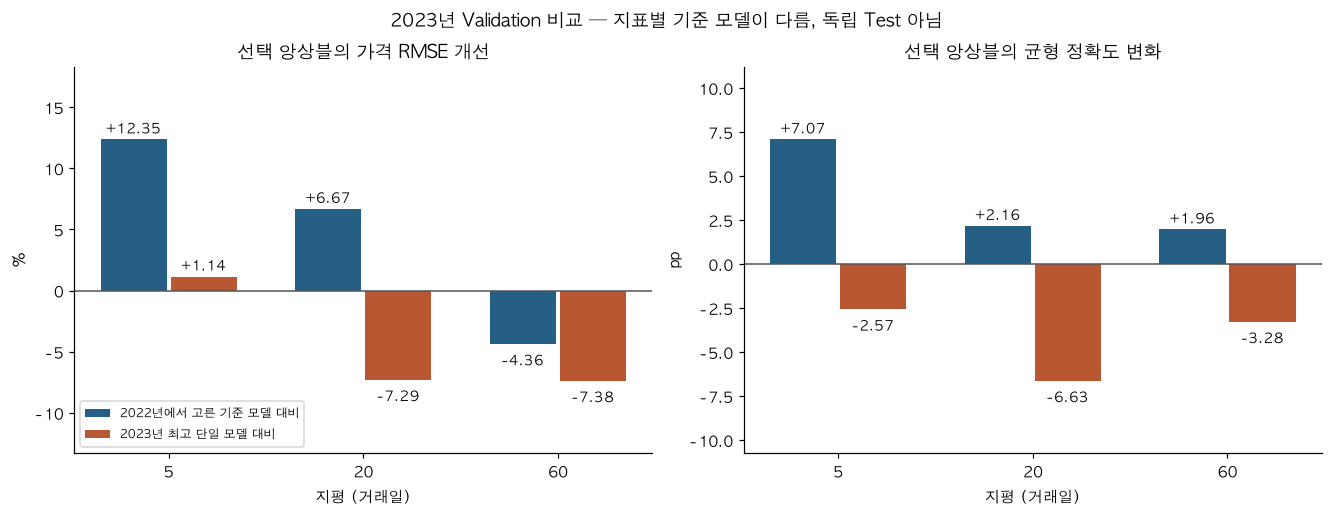

In [5]:
selection_rows, gain_rows = [], []
MODE_ORDER={"원평균":0,"편향만":1,"편향+뉴스":2,"역방향 허용 뉴스":3}
for h in HORIZONS:
    current=evaluation.loc[(evaluation["연도"]==2023)&(evaluation["지평"]==h)].copy()
    rm=current.loc[current["조합"].eq(anchors.loc[h,"RMSE 핵심"])].iloc[0]
    dm=current.loc[current["조합"].eq(anchors.loc[h,"방향 최고"])].iloc[0]
    current["상대 오차 합"]=[joint_score(row,rm["가격 RMSE"],dm["균형 정확도 (%)"]) for row in current.to_dict("records")]
    current["보정 순서"]=current["보정"].map(MODE_ORDER)
    final=current.loc[current["최종 선택 허용"]].sort_values(
        ["상대 오차 합","가격 RMSE","구성원 수","보정 순서","조합"]).iloc[0]
    singles=current.loc[current["조합"].isin(MODELS)]
    best_rm=singles.sort_values(["가격 RMSE","조합"]).iloc[0]
    best_dm=singles.sort_values(["균형 정확도 (%)","가격 RMSE"],ascending=[False,True]).iloc[0]
    selection_rows.append({**final.to_dict(),"RMSE 비교 모델":rm["조합"],"방향 비교 모델":dm["조합"],
        "단일 RMSE 핵심 대비 개선 (%)":100*(1-final["가격 RMSE"]/rm["가격 RMSE"]),
        "단일 방향 핵심 대비 균형 변화 (pp)":final["균형 정확도 (%)"]-dm["균형 정확도 (%)"],
        "2023 RMSE 최저 단일":best_rm["조합"],"2023 단일 최저 RMSE":best_rm["가격 RMSE"],
        "2023 방향 최고 단일":best_dm["조합"],"2023 단일 최고 균형 (%)":best_dm["균형 정확도 (%)"],
        "2023 최저 단일 RMSE 대비 개선 (%)":100*(1-final["가격 RMSE"]/best_rm["가격 RMSE"]),
        "2023 최고 단일 균형 대비 변화 (pp)":final["균형 정확도 (%)"]-best_dm["균형 정확도 (%)"],
        "단일 모델에 열세":bool(((singles["가격 RMSE"]<=final["가격 RMSE"]) &
            (singles["균형 정확도 (%)"]>=final["균형 정확도 (%)"])).any())})
    for name in frozen[h]:
        trio=current.loc[current["조합"].eq(name)].set_index("보정")
        base,bias=trio.loc["원평균"],trio.loc["편향만"]
        for mode in ("편향+뉴스","역방향 허용 뉴스"):
            news=trio.loc[mode]
            gain_rows.append({"지평":h,"조합":name,"보정":mode,"원평균 가격 RMSE":base["가격 RMSE"],
                "편향만 가격 RMSE":bias["가격 RMSE"],"뉴스 가격 RMSE":news["가격 RMSE"],
                "뉴스 추가 RMSE 개선 (%)":100*(1-news["가격 RMSE"]/bias["가격 RMSE"]),
                "뉴스 추가 균형 변화 (pp)":news["균형 정확도 (%)"]-bias["균형 정확도 (%)"]})
selection=pd.DataFrame(selection_rows);news_gains=pd.DataFrame(gain_rows)
show(selection[["지평","조합","구성원 수","보정","가격 RMSE","방향 적중률 (%)","균형 정확도 (%)",
    "단일 RMSE 핵심 대비 개선 (%)","단일 방향 핵심 대비 균형 변화 (pp)"]])
show(selection[["지평","2023 RMSE 최저 단일","2023 단일 최저 RMSE","2023 최저 단일 RMSE 대비 개선 (%)",
    "2023 방향 최고 단일","2023 단일 최고 균형 (%)","2023 최고 단일 균형 대비 변화 (pp)","단일 모델에 열세"]])
show(news_gains)

def paired_interval(frame,predicted,baseline,block,repeats=1000):
    y=frame.actual_return.to_numpy(float);p=np.asarray(predicted,float);b=np.asarray(baseline,float)
    score(y,p,frame.current_price);score(y,b,frame.current_price)
    n=len(y)
    if not 1<=block<=n: raise ValueError("블록 길이 오류")
    gain=(frame.current_price.to_numpy()*(np.exp(y)-np.exp(b)))**2-(frame.current_price.to_numpy()*(np.exp(y)-np.exp(p)))**2
    starts=np.random.default_rng(SEED).integers(0,n,(repeats,int(np.ceil(n/block))))
    ix=((starts[...,None]+np.arange(block))%n).reshape(repeats,-1)[:,:n]
    lo,hi=np.quantile(gain[ix].mean(axis=1),[.025,.975])
    return {"가격 MSE 개선":gain.mean(),"95% 하한":lo,"95% 상한":hi}

interval_rows,offset_rows=[] ,[]
for h in HORIZONS:
    r,p=panels[(2023,h)]
    pd.testing.assert_index_equal(r.index.rename(None),coffee_sessions(r.index.min(),r.index.max()).rename(None))
    def get_prediction(name,mode):
        sub=forecasts.loc[(forecasts.year==2023)&(forecasts.horizon==h)&forecasts.candidate.eq(name)&forecasts["mode"].eq(mode)].set_index("origin_date")
        pd.testing.assert_index_equal(sub.index,r.index)
        return sub.predicted_return.to_numpy()
    row=selection.loc[selection["지평"].eq(h)].iloc[0]
    selected=get_prediction(row["조합"],row["보정"])
    reference=p[anchors.loc[h,"RMSE 핵심"]].to_numpy()
    comparisons=[("선택 후보−2022 RMSE 핵심",row["조합"],selected,reference),
                 ("선택 후보−2023 RMSE 최저 단일",row["조합"],selected,p[row["2023 RMSE 최저 단일"]].to_numpy())]
    for name in frozen[h]:
        for mode in ("편향+뉴스","역방향 허용 뉴스"):
            comparisons.append((mode+"−편향만",name,get_prediction(name,mode),get_prediction(name,"편향만")))
    for label,name,pred,base in comparisons:
        for block in (h,2*h):
            interval_rows.append({"지평":h,"비교":label,"조합":name,"블록":block,**paired_interval(r,pred,base,block)})
    for offset in range(h):
        mask=np.arange(len(r))%h==offset
        sub=r.loc[mask]
        assert (sub.index[1:]>=sub.target_date.iloc[:-1].to_numpy()).all()
        a,b=score(sub.actual_return,selected[mask],sub.current_price),score(sub.actual_return,reference[mask],sub.current_price)
        offset_rows.append({"지평":h,"offset":offset,**a,"단일 RMSE 핵심 대비 개선 (%)":100*(1-a["가격 RMSE"]/b["가격 RMSE"])})
intervals=pd.DataFrame(interval_rows);offsets=pd.DataFrame(offset_rows)
show(intervals)
show(offsets.groupby("지평",as_index=False).agg(최소표본=("표본","min"),최대표본=("표본","max"),
    최소개선=("단일 RMSE 핵심 대비 개선 (%)","min"),중앙개선=("단일 RMSE 핵심 대비 개선 (%)","median"),
    최대개선=("단일 RMSE 핵심 대비 개선 (%)","max")))
fig,axes=plt.subplots(1,2,figsize=(12,4.6),constrained_layout=True)
for ax,columns,title,unit in zip(axes,
        [("단일 RMSE 핵심 대비 개선 (%)","2023 최저 단일 RMSE 대비 개선 (%)"),
         ("단일 방향 핵심 대비 균형 변화 (pp)","2023 최고 단일 균형 대비 변화 (pp)")],
        ["선택 앙상블의 가격 RMSE 개선","선택 앙상블의 균형 정확도 변화"],["%","pp"]):
    for shift,column,color,label in zip([-.18,.18],columns,["#255F85","#B95732"],
            ["2022년에서 고른 기준 모델 대비","2023년 최고 단일 모델 대비"]):
        values=selection[column].to_numpy();positions=np.arange(3)+shift
        ax.bar(positions,values,width=.34,color=color,label=label)
        for pos,value in zip(positions,values): ax.annotate(f"{value:+.2f}",(pos,value),
            xytext=(0,4 if value>=0 else -14),textcoords="offset points",ha="center",fontsize=9)
    ax.axhline(0,color="#555555",linewidth=1);ax.margins(y=.3)
    ax.set(xticks=range(3),xticklabels=HORIZONS,xlabel="지평 (거래일)",ylabel=unit,title=title)
axes[0].legend(loc="lower left",fontsize=8)
fig.suptitle("2023년 Validation 비교 — 지표별 기준 모델이 다름, 독립 Test 아님")
plt.show()

## 5. 실행 검사·결과 저장·판단

뉴스/가격 자료와 기존 예측의 해시를 남긴다. 새로운 2024~2026년 평가를 실행하지 않았고, 최종 선택 후 재학습·실서비스 교체도 하지 않는다. 뉴스 자료는 소급 분석이라는 조건을 유지한다. 저장한 2022년 점수에는 조합 선별과 보정 적합 효과가 포함되며 2023년 점수와 섞어 일반화 점수로 요약하지 않는다.

In [6]:
# 입력 경계와 보정 수식·미래 정보 불변성 검사
missing=chosen.loc[chosen.fold.eq("2022") & chosen.horizon.eq(5)].copy()
missing=missing.drop(missing.loc[missing.model.eq("TimesNet")].index[0])
try: align(missing)
except AssertionError: pass
else: raise AssertionError("모델별 평가 날짜 불일치를 허용했습니다.")
probe=pd.DataFrame({"DLinear":np.log([1.,2.]),"NLinear":np.log([3.,4.])})
np.testing.assert_allclose(np.exp(price_average(probe,("DLinear","NLinear"))),[2.,3.])
try: price_average(probe,("DLinear","Persistence"))
except ValueError: pass
else: raise AssertionError("허용하지 않은 모델이 평균에 포함됐습니다.")
probe_r=pd.DataFrame({"target_date":pd.to_datetime(["2022-01-10","2022-01-11","2022-01-12"]),
    "news_x":[-.1,0,.1],"actual_return":np.log([.9,1.,1.1]),"current_price":[100.,100.,100.]})
fit,_=fit_news(probe_r,np.zeros(3));np.testing.assert_allclose(fit["편향+뉴스"],[0,1],atol=1e-12)
np.testing.assert_allclose(corrected(np.zeros(3),probe_r.news_x,*fit["편향+뉴스"]),probe_r.actual_return)
probe_r["news_x"] *= -1
negative_fit,diagnostic=fit_news(probe_r,np.zeros(3))
assert negative_fit["편향+뉴스"][1]==0
np.testing.assert_allclose(negative_fit["역방향 허용 뉴스"],[0,-1],atol=1e-12)
assert diagnostic["제한 전 beta"]<0
assert MODE_ORDER["편향만"]<MODE_ORDER["편향+뉴스"]
probe_r.loc[0,"target_date"]=pd.Timestamp("2023-01-01")
try: fit_news(probe_r,np.zeros(3))
except ValueError: pass
else: raise AssertionError("미성숙/2023 정답이 계수 적합에 사용됐습니다.")
# 미래 기사만 제거했을 때 과거 피처는 동일해야 한다.
probe_dates=news_sessions[:30];boundary=probe_dates.max().tz_localize("UTC")+pd.Timedelta(hours=23)
earlier=[row for row in records if pd.Timestamp(row["event_at"])<=boundary and pd.Timestamp(row["selection_available_at"])<=boundary]
pd.testing.assert_frame_equal(signal_features(earlier,probe_dates,availability="research"),features.loc[probe_dates])
assert not forecasts.duplicated(["year","horizon","candidate","mode","origin_date"]).any()
assert forecasts.origin_date.dt.year.isin([2022,2023]).all() and forecasts.target_date.le(SELECT_END).all()
assert not forecasts.candidate.str.contains("Naive|Persistence",regex=True).any()
assert np.isfinite(forecasts[["predicted_return","actual_return","current_price","news_x"]]).all().all()
for h,by_name in frozen.items():
    assert all(set(members)<=set(MODELS) and len({FAMILY[m] for m in members})>=2 for members in by_name.values())
    for name in by_name:
        row=candidates.loc[(candidates["지평"]==h)&candidates["조합"].eq(name)].iloc[0]
        assert row["다양성 통과"] and row["최대 오차상관"]<=CORR_CAP
for row in selection.to_dict("records"):
    assert row["조합"] in anchors.loc[row["지평"],"최종 선택 허용 조합"]
    coefficient=parameters.loc[(parameters["지평"]==row["지평"])&parameters["조합"].eq(row["조합"])&parameters["보정"].eq(row["보정"])].iloc[0]
    assert coefficient.beta != 0 or row["보정"] not in ("편향+뉴스","역방향 허용 뉴스"), "동률은 단순 보정 우선"
    sub=forecasts.loc[(forecasts.year==2023)&(forecasts.horizon==row["지평"])&forecasts.candidate.eq(row["조합"])&forecasts["mode"].eq(row["보정"])]
    np.testing.assert_allclose(score(sub.actual_return,sub.predicted_return,sub.current_price)["가격 RMSE"],row["가격 RMSE"])
    r,_=panels[(2023,row["지평"])]
    assert all(value==0 for value in paired_interval(r,sub.predicted_return,sub.predicted_return,row["지평"]).values())
print("통과: Validation/성숙 정답·허용 모델·산술평균·뉴스 양의/음의 효과·미래 기사 불변·지표 대조")

# 네 파일 묶음을 완성한 뒤 공개하고 같은 결과만 재저장한다.
key=hashlib.sha256((source_hash+news_hash+market_hash+"validation-ensemble-news-v2").encode()).hexdigest()[:16]
OUTPUT=ROOT/"data/processed/validation_ensemble_news"/key
OUTPUT.parent.mkdir(parents=True,exist_ok=True)
all_tables=pd.concat([setting_scores.assign(표="2022 설정"),candidates.assign(표="2022 조합"),
    parameters.assign(표="2022 뉴스 계수"),selection.assign(표="2023 최종 선택"),news_gains.assign(표="2023 뉴스 추가"),
    intervals.assign(표="2023 블록 구간"),news_audit.assign(표="뉴스 감사")],ignore_index=True)
with tempfile.TemporaryDirectory(prefix=".validation-news-",dir=OUTPUT.parent) as temp:
    stage=Path(temp)
    forecasts.to_parquet(stage/"individual_predictions.parquet",index=False)
    all_tables.to_csv(stage/"metrics.csv",index=False)
    evaluation.to_csv(stage/"yearly_metrics.csv",index=False)
    offsets.to_csv(stage/"nonoverlap_metrics.csv",index=False)
    if OUTPUT.exists():
        if {p.name for p in OUTPUT.iterdir()}!={p.name for p in stage.iterdir()}: raise FileExistsError("기존 결과 구조 충돌")
        for path in stage.iterdir():
            if path.suffix==".parquet": pd.testing.assert_frame_equal(pd.read_parquet(OUTPUT/path.name),forecasts,check_exact=True)
            elif path.read_bytes()!=(OUTPUT/path.name).read_bytes(): raise FileExistsError("기존 결과 값 충돌")
    else:stage.rename(OUTPUT)
print("저장:",OUTPUT.relative_to(ROOT))
print("SHA256:",{"predictions":source_hash,"news":news_hash,"market":market_hash})
for row in selection.to_dict("records"):
    h,name,mode=row["지평"],row["조합"],row["보정"]
    display(Markdown(f"- **{h}일 앙상블 내 Validation 선택:** {name} / {mode}. 가격 RMSE **{row['가격 RMSE']:.4f}**, "
        f"방향 적중률 **{row['방향 적중률 (%)']:.2f}%**, 균형 정확도 **{row['균형 정확도 (%)']:.2f}%**. "
        f"2022년 RMSE 핵심 대비 **{row['단일 RMSE 핵심 대비 개선 (%)']:+.2f}%**이나, "
        f"2023년 최저 RMSE 단일 모델 {row['2023 RMSE 최저 단일']} "
        f"(RMSE {row['2023 단일 최저 RMSE']:.4f}) 대비 **{row['2023 최저 단일 RMSE 대비 개선 (%)']:+.2f}%**다. "
        f"단일 모델에 RMSE·균형 정확도 모두 열세: **{row['단일 모델에 열세']}**."))
    if mode in ("편향+뉴스","역방향 허용 뉴스"):
        effect=news_gains.loc[(news_gains["지평"]==h)&news_gains["조합"].eq(name)&news_gains["보정"].eq(mode)].iloc[0]
        display(Markdown(f"  같은 조합의 편향 대조군 대비 뉴스 추가 효과: RMSE "
            f"**{effect['뉴스 추가 RMSE 개선 (%)']:+.2f}%**, 균형 정확도 **{effect['뉴스 추가 균형 변화 (pp)']:+.2f}pp**."))
display(Markdown("**판단 범위:** 이 선택은 재사용한 Validation 후보 선택이며 독립 Test 검증이 아니다. "
    "단일 모델에 두 지표 모두 열세이면 앙상블 채택 근거가 없다. 낮은 오차상관이나 구성원 수 증가가 개선을 보장하지 않는다. "
    "감성 방향 유지 계수 0은 음의 관계를 제한한 결과일 수 있어 제한 전 계수와 역방향 결과를 함께 봐야 한다. "
    "뉴스가 더해져도 편향 대조군보다 못하면 뉴스 효과라고 부르지 않는다. "
    "2026년 소급 분류·기사 누락·1년 비교 한계가 남으므로 새로운 기간의 검증 전에는 매입비 절감이나 서비스 교체를 확정하지 않는다."))

통과: Validation/성숙 정답·허용 모델·산술평균·뉴스 양의/음의 효과·미래 기사 불변·지표 대조
저장: data/processed/validation_ensemble_news/b2c3c63149beb2f6
SHA256: {'predictions': '35035873ee7b3818d21180ffc7530362b2723740d649ad9cda8d23182f4e38e8', 'news': '673adfffa85de511e1f33dbc93fab71d5f84455aeaf4c41c9b2d77e827ffc110', 'market': '2355aab560717a47333742adea40994ab537ef171be7f03501bbc3fcf270b503'}


- **5일 앙상블 내 Validation 선택:** NLinear + XGBoost + TimesNet / 역방향 허용 뉴스. 가격 RMSE **7.5925**, 방향 적중률 **58.78%**, 균형 정확도 **59.17%**. 2022년 RMSE 핵심 대비 **+12.35%**이나, 2023년 최저 RMSE 단일 모델 TimesNet (RMSE 7.6802) 대비 **+1.14%**다. 단일 모델에 RMSE·균형 정확도 모두 열세: **False**.

  같은 조합의 편향 대조군 대비 뉴스 추가 효과: RMSE **+4.47%**, 균형 정확도 **+5.63pp**.

- **20일 앙상블 내 Validation 선택:** DLinear + NLinear + XGBoost + PatchTST + TimesNet / 역방향 허용 뉴스. 가격 RMSE **16.8251**, 방향 적중률 **55.65%**, 균형 정확도 **55.15%**. 2022년 RMSE 핵심 대비 **+6.67%**이나, 2023년 최저 RMSE 단일 모델 XGBoost (RMSE 15.6822) 대비 **-7.29%**다. 단일 모델에 RMSE·균형 정확도 모두 열세: **True**.

  같은 조합의 편향 대조군 대비 뉴스 추가 효과: RMSE **+1.58%**, 균형 정확도 **+1.82pp**.

- **60일 앙상블 내 Validation 선택:** DLinear + NLinear + LightGBM / 편향만. 가격 RMSE **31.2559**, 방향 적중률 **53.68%**, 균형 정확도 **53.51%**. 2022년 RMSE 핵심 대비 **-4.36%**이나, 2023년 최저 RMSE 단일 모델 XGBoost (RMSE 29.1091) 대비 **-7.38%**다. 단일 모델에 RMSE·균형 정확도 모두 열세: **True**.

**판단 범위:** 이 선택은 재사용한 Validation 후보 선택이며 독립 Test 검증이 아니다. 단일 모델에 두 지표 모두 열세이면 앙상블 채택 근거가 없다. 낮은 오차상관이나 구성원 수 증가가 개선을 보장하지 않는다. 감성 방향 유지 계수 0은 음의 관계를 제한한 결과일 수 있어 제한 전 계수와 역방향 결과를 함께 봐야 한다. 뉴스가 더해져도 편향 대조군보다 못하면 뉴스 효과라고 부르지 않는다. 2026년 소급 분류·기사 누락·1년 비교 한계가 남으므로 새로운 기간의 검증 전에는 매입비 절감이나 서비스 교체를 확정하지 않는다.